	AUTHOR:[UZAIR-UR-REHMAN]

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ── 1. Data Generation ───────────────────────────────────────────────────────
np.random.seed(42)                        # reproducible results
R_true = 1000                             # Ω

I_flat = np.linspace(0, 0.01, 50)        # 0 to 10 mA in Amperes
V_clean = R_true * I_flat                 # 0 to 10 V
noise   = np.random.normal(0, 0.05, size=I_flat.shape)  # noise std 0.05 V (was 0.2!)   #x_normal=x - u or mean/standard deviation
V_noisy = V_clean + noise

In [5]:
# ── 3. Normalize for Gradient Descent ────────────────────────────────────────
I_mean, I_std = I_flat.mean(), I_flat.std()
V_mean, V_std = V_noisy.mean(), V_noisy.std()

I_norm = (I_flat - I_mean) / I_std
V_norm = (V_noisy - V_mean) / V_std

Converged at epoch 239

GD slope     : 997.10 Ω  (expected 1000)
GD intercept : 0.0032 V  (expected ~0)


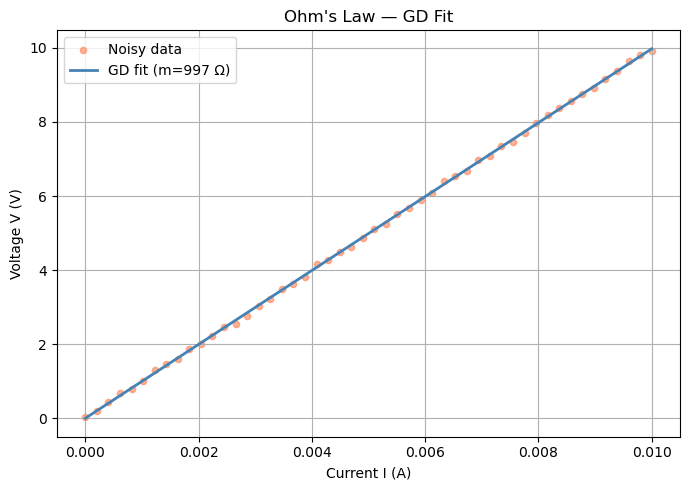

In [8]:
# ── 4. Gradient Descent ───────────────────────────────────────────────────────
alpha = 0.05
m, b  = 1.0, 100.0
loss_history = []

for epoch in range(500):
    V_pred = m * I_norm + b
    error  = V_pred - V_norm

    loss = (error ** 2).mean()
    loss_history.append(float(loss))  # save currebt value and after we want to see 

    dm = 2 * (I_norm * error).mean()
    db = 2 * error.mean()

    m -= alpha * dm
    b -= alpha * db

    if epoch > 0 and abs(loss_history[-2] - loss_history[-1]) < 1e-20:
        print(f"Converged at epoch {epoch}")
        break

# ── 5. Rescale back to physical units ────────────────────────────────────────
m_phys = m * (V_std / I_std)
b_phys = b * V_std + V_mean - m_phys * I_mean

print(f"\nGD slope     : {m_phys:.2f} Ω  (expected 1000)")
print(f"GD intercept : {b_phys:.4f} V  (expected ~0)")

# ── 6. Plots ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(I_flat, V_noisy, s=20, alpha=0.6, color="coral", label="Noisy data")
ax.plot(I_flat, m_phys * I_flat + b_phys,
        color="steelblue", linewidth=2, label=f"GD fit (m={m_phys:.0f} Ω)")
ax.set_xlabel("Current I (A)")
ax.set_ylabel("Voltage V (V)")
ax.set_title("Ohm's Law — GD Fit")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

## Gradient Descent — Mathematical Formulation

**Prediction:**

$$\hat{V}_i = m \cdot I_i^{norm} + b$$

**Error:**

$$e_i = \hat{V}_i - V_i^{norm}$$

**Loss Function (Mean Squared Error):**

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} e_i^2$$

**Gradients:**

$$\frac{\partial \mathcal{L}}{\partial m} = \frac{2}{N} \sum_{i=1}^{N} I_i^{norm} \cdot e_i$$

$$\frac{\partial \mathcal{L}}{\partial b} = \frac{2}{N} \sum_{i=1}^{N} e_i$$

**Parameter Update:**

$$m \leftarrow m - \alpha \cdot \frac{\partial \mathcal{L}}{\partial m}$$

$$b \leftarrow b - \alpha \cdot \frac{\partial \mathcal{L}}{\partial b}$$

where $\alpha$ is the **learning rate**.

## Rescaling Back to Physical Units

When we normalize:

$$I_{norm} = \frac{I - \mu_I}{\sigma_I} \qquad V_{norm} = \frac{V - \mu_V}{\sigma_V}$$

GD learns in normalized space:

$$V_{norm} = m \cdot I_{norm} + b$$


## Substituting Back

Replace $I_{norm}$ and $V_{norm}$ with their definitions:

$$\frac{V - \mu_V}{\sigma_V} = m \cdot \frac{I - \mu_I}{\sigma_I} + b$$

Multiply both sides by $\sigma_V$:

$$V - \mu_V = m \cdot \frac{\sigma_V}{\sigma_I} \cdot (I - \mu_I) + b \cdot \sigma_V$$

Expand the right side:

$$V - \mu_V = m \cdot \frac{\sigma_V}{\sigma_I} \cdot I \;\;-\;\; m \cdot \frac{\sigma_V}{\sigma_I} \cdot \mu_I + b \cdot \sigma_V$$

Move $\mu_V$ to the right:

$$V = \underbrace{m \cdot \frac{\sigma_V}{\sigma_I}}_{\texttt{m\_phys}} \cdot I \;\;+\;\; \underbrace{b \cdot \sigma_V + \mu_V - m \cdot \frac{\sigma_V}{\sigma_I} \cdot \mu_I}_{\texttt{b\_phys}}$$

Therefore:

$$\boxed{m_{phys} = m \times \frac{\sigma_V}{\sigma_I}}$$

$$\boxed{b_{phys} = b \times \sigma_V + \mu_V - m_{phys} \times \mu_I}$$